In [1]:
import os
import numpy as np
import copy

%matplotlib notebook
import matplotlib as mpl
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt

import numpy as np
from scipy.integrate import quad
from scipy.interpolate import make_interp_spline
from numpy.polynomial import polynomial

In [2]:
from icecube.icetray import OMKey
from icecube.dataclasses import ModuleKey
from icecube import dataio, dataclasses, simclasses

Set appropriate environmental variables here

In [3]:
%env PONESRCDIR /home/users/fhenningsen/pone_offline
%env PONEDATA /data/p-one/fhenningsen

env: PONESRCDIR=/home/users/fhenningsen/pone_offline
env: PONEDATA=/data/p-one/fhenningsen


In [5]:
from WaterOpticalModel import MakePoneMediumPropertiesConservativeExtendedRange as Medium
from Utilities import DOMUtility

## Check GCD

In [6]:
#Using new GCD:
geometry = dataio.I3File('%s/GCD/PONE_Phase1.i3.gz' %(os.environ.get('PONESRCDIR')))

gframe = geometry.pop_frame()  
geo = gframe["I3Geometry"] #access geo file via key
all_dom_keys = geo.omgeo.keys()

print(all_dom_keys[:5])
print('...')
print(all_dom_keys[-5:])

[OMKey(1,1,1), OMKey(1,1,2), OMKey(1,1,3), OMKey(1,1,4), OMKey(1,1,5)]
...
[OMKey(10,20,12), OMKey(10,20,13), OMKey(10,20,14), OMKey(10,20,15), OMKey(10,20,16)]


In [7]:
for i in all_dom_keys[::1970]:
    print(i, geo.omgeo[i])

OMKey(1,1,1) [I3OMGeo Position: I3Position(12.5,-21.6506,-450)
      Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
           OMType: 130
             Area: 0.585754 ]
OMKey(7,4,3) [I3OMGeo Position: I3Position(-12.5,21.6506,-300)
      Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
           OMType: 130
             Area: 0.585754 ]


<IPython.core.display.Javascript object>


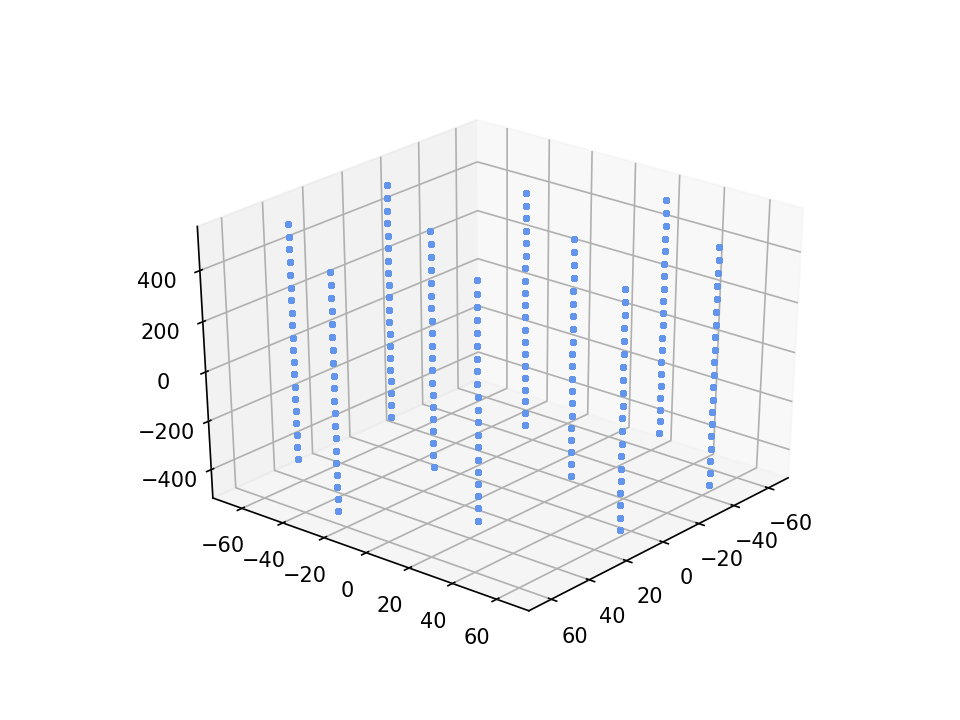

In [103]:
fig = plt.figure()
ax = plt.axes(projection='3d')

for i in all_dom_keys:
    om = geo.omgeo[i]
    x, y, z = om.position
    ax.scatter(x, y, z, color='cornflowerblue', s=5)
    ax.view_init(30, 40)

## Check optical properties

In [104]:
m = Medium.MakePoneMediumProperties()

In [105]:
# from WaterOpticalModule/MakePoneMediumPropertiesConservativeExtendedRange.py
# https://github.com/pone-software/pone_offline/blob/608423314880fe96e9bebf191923a9dd111aefa6/WaterOpticalModel/MakePoneMediumPropertiesConservativeExtendedRange.py
absLenTable = [ 0.800,   1.629,   2.457,   3.286,   4.114,   4.943,   5.771,   6.600,   7.429,
                8.257,   9.086,  10.214,  11.643,  13.071,  14.500,  17.520,  20.540,  23.560,
               26.580,  29.600,  27.911,  26.222,  24.533,  22.844,  21.156,  19.467,  17.778,
               16.089,  14.400,  12.711,  11.022,   9.333,   7.644,   6.563,   6.089,   5.615,
                5.141,   4.667,   4.193,   3.720,   3.246,   2.772,   2.298,   1.824,   1.350,
                0.876]
wls = np.linspace(m.GetMinWavelength(), m.GetMaxWavelength(), len(absLenTable)) * 1e9

<IPython.core.display.Javascript object>


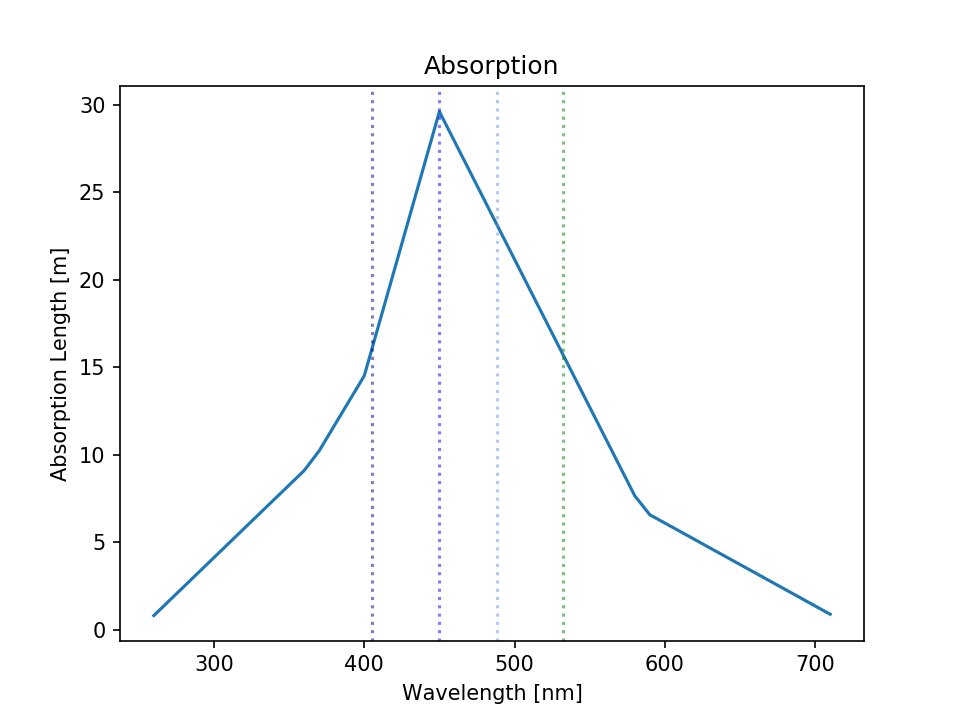

In [106]:
plt.figure()
plt.plot(wls, absLenTable)
plt.axvline(405, ls=':', alpha=0.5, color='darkblue')
plt.axvline(450, ls=':', alpha=0.5, color='blue')
plt.axvline(488, ls=':', alpha=0.5, color='cornflowerblue')
plt.axvline(532, ls=':', alpha=0.5, color='green')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorption Length [m]')
plt.title('Absorption')
plt.show()

In [107]:
# from WaterOpticalModule/MakePoneMediumPropertiesConservativeExtendedRange.py
# https://github.com/pone-software/pone_offline/blob/608423314880fe96e9bebf191923a9dd111aefa6/WaterOpticalModel/MakePoneMediumPropertiesConservativeExtendedRange.py

# petzold scattering angle distribution
deg = np.pi/180.

petzold_powerLawIndexBeforeFirstBin = -1.346
petzold_data_ang = [1e-9,
                    0.100*deg,   0.126*deg,   0.158*deg,   0.200*deg,   0.251*deg,
                    0.316*deg,   0.398*deg,   0.501*deg,   0.631*deg,   0.794*deg,
                    1.000*deg,   1.259*deg,   1.585*deg,   1.995*deg,   2.512*deg,
                    3.162*deg,   3.981*deg,   5.012*deg,   6.310*deg,   7.943*deg,
                    10.000*deg,  15.000*deg,  20.000*deg,  25.000*deg,  30.000*deg,
                    35.000*deg,  40.000*deg,  45.000*deg,  50.000*deg,  55.000*deg,
                    60.000*deg,  65.000*deg,  70.000*deg,  75.000*deg,  80.000*deg,
                    85.000*deg,  90.000*deg,  95.000*deg, 100.000*deg, 105.000*deg,
                    110.000*deg, 115.000*deg, 120.000*deg, 125.000*deg, 130.000*deg,
                    135.000*deg, 140.000*deg, 145.000*deg, 150.000*deg, 155.000*deg,
                    160.000*deg, 165.000*deg, 170.000*deg, 175.000*deg, 180.000*deg]
petzold_data_val=[0.,  # <- this 0 will be replaced right after the definition
                  1.767e+03, 1.296e+03, 9.502e+02, 6.991e+02, 5.140e+02,
                  3.764e+02, 2.763e+02, 2.188e+02, 1.444e+02, 1.022e+02,
                  7.161e+01, 4.958e+01, 3.395e+01, 2.281e+01, 1.516e+01,
                  1.002e+01, 6.580e+00, 4.295e+00, 2.807e+00, 1.819e+00,
                  1.153e+00, 4.893e-01, 2.444e-01, 1.472e-01, 8.609e-02,
                  5.931e-02, 4.210e-02, 3.067e-02, 2.275e-02, 1.699e-02,
                  1.313e-02, 1.046e-02, 8.488e-03, 6.976e-03, 5.842e-03,
                  4.953e-03, 4.292e-03, 3.782e-03, 3.404e-03, 3.116e-03,
                  2.912e-03, 2.797e-03, 2.686e-03, 2.571e-03, 2.476e-03,
                  2.377e-03, 2.329e-03, 2.313e-03, 2.365e-03, 2.506e-03,
                  2.662e-03, 2.835e-03, 3.031e-03, 3.092e-03, 3.154e-03]
# power law for values below bin 1
petzold_data_val[0] = 2.*np.pi*np.sin(petzold_data_ang[1])*petzold_data_val[1] * \
                       ((petzold_data_ang[0]/petzold_data_ang[1])**petzold_powerLawIndexBeforeFirstBin)

for i in range(len(petzold_data_val)):
    petzold_data_val[i] = 2.*np.pi*petzold_data_val[i]*np.sin(petzold_data_ang[i])

<IPython.core.display.Javascript object>


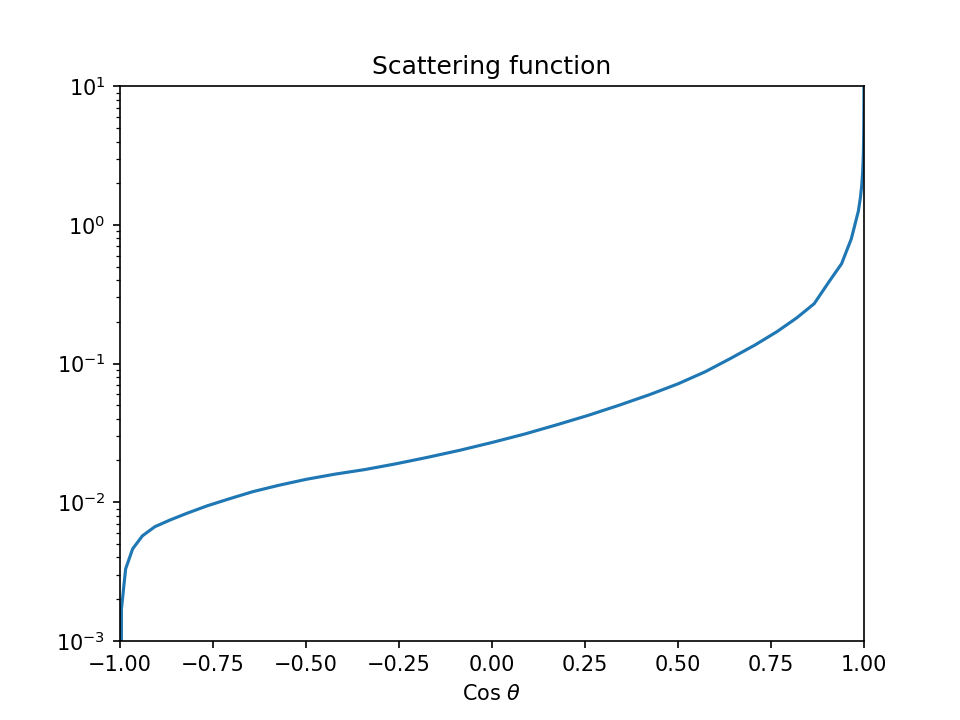

In [108]:
plt.figure()
plt.plot(np.cos(petzold_data_ang), petzold_data_val)
plt.yscale('log')
plt.xlim(-1, 1)
plt.ylim(1e-3, 1e1)
plt.xlabel('Cos $\\theta$')
plt.title('Scattering function')
plt.show()

## Check the data

In [204]:
d = 'isotropic/sim_isotropic-test_2022-06-13_21-13-03'
f = 'isotropic-test_detect-emitter-1_flasher-key-5-10_fwhm-5.0_num-events-100_num-photons-10000000000_oversize-1.0.i3.bz2'
f = os.path.join(os.environ.get('PONEDATA'), d, 'simulation', f)

In [205]:
# d = 'isotropic/sim_isotropic-angular-acc-test_2022-06-16_00-02-03'
# f = 'isotropic-angular-acc-test_detect-emitter-1_flasher-key-5-10_fwhm-5.0_num-events-100_num-photons-10000000000_oversize-1.0.i3.bz2'
# f = os.path.join(os.environ.get('PONEDATA'), d, 'simulation', f)

In [223]:
d = 'Flasher/Isotropic'
f = 'test.i3.bz2'
f = os.path.join(os.environ.get('PONESRCDIR'), d, f)

In [224]:
i3f = dataio.I3File(f)

In [225]:
frame = i3f.pop_daq()

In [226]:
frame.keys()

['SPEAbove',
 'SPEScalingFactors',
 'I3EventHeader',
 'I3Photons',
 'MCTimeIncEventID',
 'BadDomsListSLC',
 'FlasherPulseSeries',
 'BadDomsList',
 'I3DetectorStatus',
 'Subdetectors',
 'I3ModuleGeoMap',
 'StartTime',
 'I3OMGeoMap',
 'EndTime',
 'I3Calibration',
 'I3Geometry']

In [227]:
print(frame['I3EventHeader'])

[ I3EventHeader:
        StartTime: 2022-01-10 05:20:50.961,584,445,8 UTC
         EndTime : 1905-06-04 18:35:44.000,000,000,0 UTC
           RunID : 1
        SubrunID : 0
         EventID : 1
      SubEventID : 0
  SubEventStream : 
]


In [228]:
print(frame['FlasherPulseSeries'])

[[I3CLSimFlasherPulse:
              Pulse Type: 3
               Direction: I3Direction(Zenith (deg): 180, Azimuth(deg): 180)
                Position: I3Position(12.5,-21.6506,-450)
                    Time: 0
    Num. Photons no bias: 1e+09
             Pulse Width: 5
      Anular Sigma Polar: 31.4159
  Anular Sigma Azimuthal: 6.28319
]]


In [229]:
ph = frame['I3Photons']

In [230]:
for i in ph.iteritems():
    print(i[0], len(i[1]), i[1][0].time, type(i[0]))

ModuleKey(1,1) 362215 8.245096206665039 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(1,2) 22896 238.00885009765625 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(1,3) 25 478.04010009765625 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(1,4) 1 723.9083251953125 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(2,1) 118 237.48252868652344 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(2,2) 23 376.1540222167969 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(3,1) 88 240.20993041992188 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(3,2) 26 335.0768737792969 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(3,3) 3 524.7030029296875 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(4,1) 171 240.35618591308594 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(4,2) 31 334.03167724609375 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(4,3) 1 521.1055908203125 <class 'icecube.dataclasses.ModuleKey'>
ModuleKey(5,1) 132 236.87156677246094 <class 'icecube.dataclasses.ModuleKey'

In [231]:
photon = i[1][0]

In [232]:
print(photon)

[I3CompressedPhoton: 
        Time: 529.406
      Weight: 1
  Wavelength: 4.11772e-07
      Zenith: 1.94192
     Azimuth: 5.14461
    Position: (-0.0950661,-0.14801,-0.124664)
  Group Vel.: 0.215463
  ParticleID: 0,0)]


In [233]:
print(photon.GetDir().zenith)

1.9419232606887817


## Plot data

In [234]:
i3f.rewind()

In [235]:
# ceate a general event dictionary with 3D array (charge, [hit times], mean hit time) as values
event = {} 
for i in all_dom_keys:
    key = ModuleKey(i[0], i[1])
    event[key] = [0,[],[],[],[]]
    
# as a first step we create a new empty data dictioniary:
data_dict = copy.deepcopy(event)

# then we read in the i3 file and iterate n frames
n = 1
for i in range(n):
    data_tmp_fr = i3f.pop_daq() # pop photon frame
    data_tmp_k = data_tmp_fr['I3Photons'] # get photon objects
    
    for c,j in enumerate(data_tmp_k.iteritems()): 
        dom_key = ModuleKey(j[0][0], j[0][1])
        hits = len(j[1])
        arrival = np.array([[j.time, j.GetDir().zenith, j.GetDir().azimuth] for j in j[1]])
        data_dict[dom_key][0] += hits # add up charge
        data_dict[dom_key][1] += arrival[:,0].tolist() # record arrival data   
        data_dict[dom_key][3] += arrival[:,1].tolist() # record arrival data   
        data_dict[dom_key][4] += arrival[:,2].tolist() # record arrival data   
        
    if i%10 == 0 and i > 0:
        print('%i frames processed.' %((i+1) * 10))
        
# and find time average over all frames
for i in all_dom_keys:
    dom_key = ModuleKey(i[0], i[1])
    data_dict[dom_key][0] = data_dict[dom_key][0] #/ float(n)
        
    if data_dict[dom_key][0] > 0: # look only at hit DOMs
        data_dict[dom_key][2] = np.mean(data_dict[dom_key][1]) # averaging time array to mean arrival time
        
    else: # set mean arrival time to 0 for non hit DOMs
        if i[2] == 16: # mask only last PMT index
            data_dict[dom_key][2] = [0]

<IPython.core.display.Javascript object>


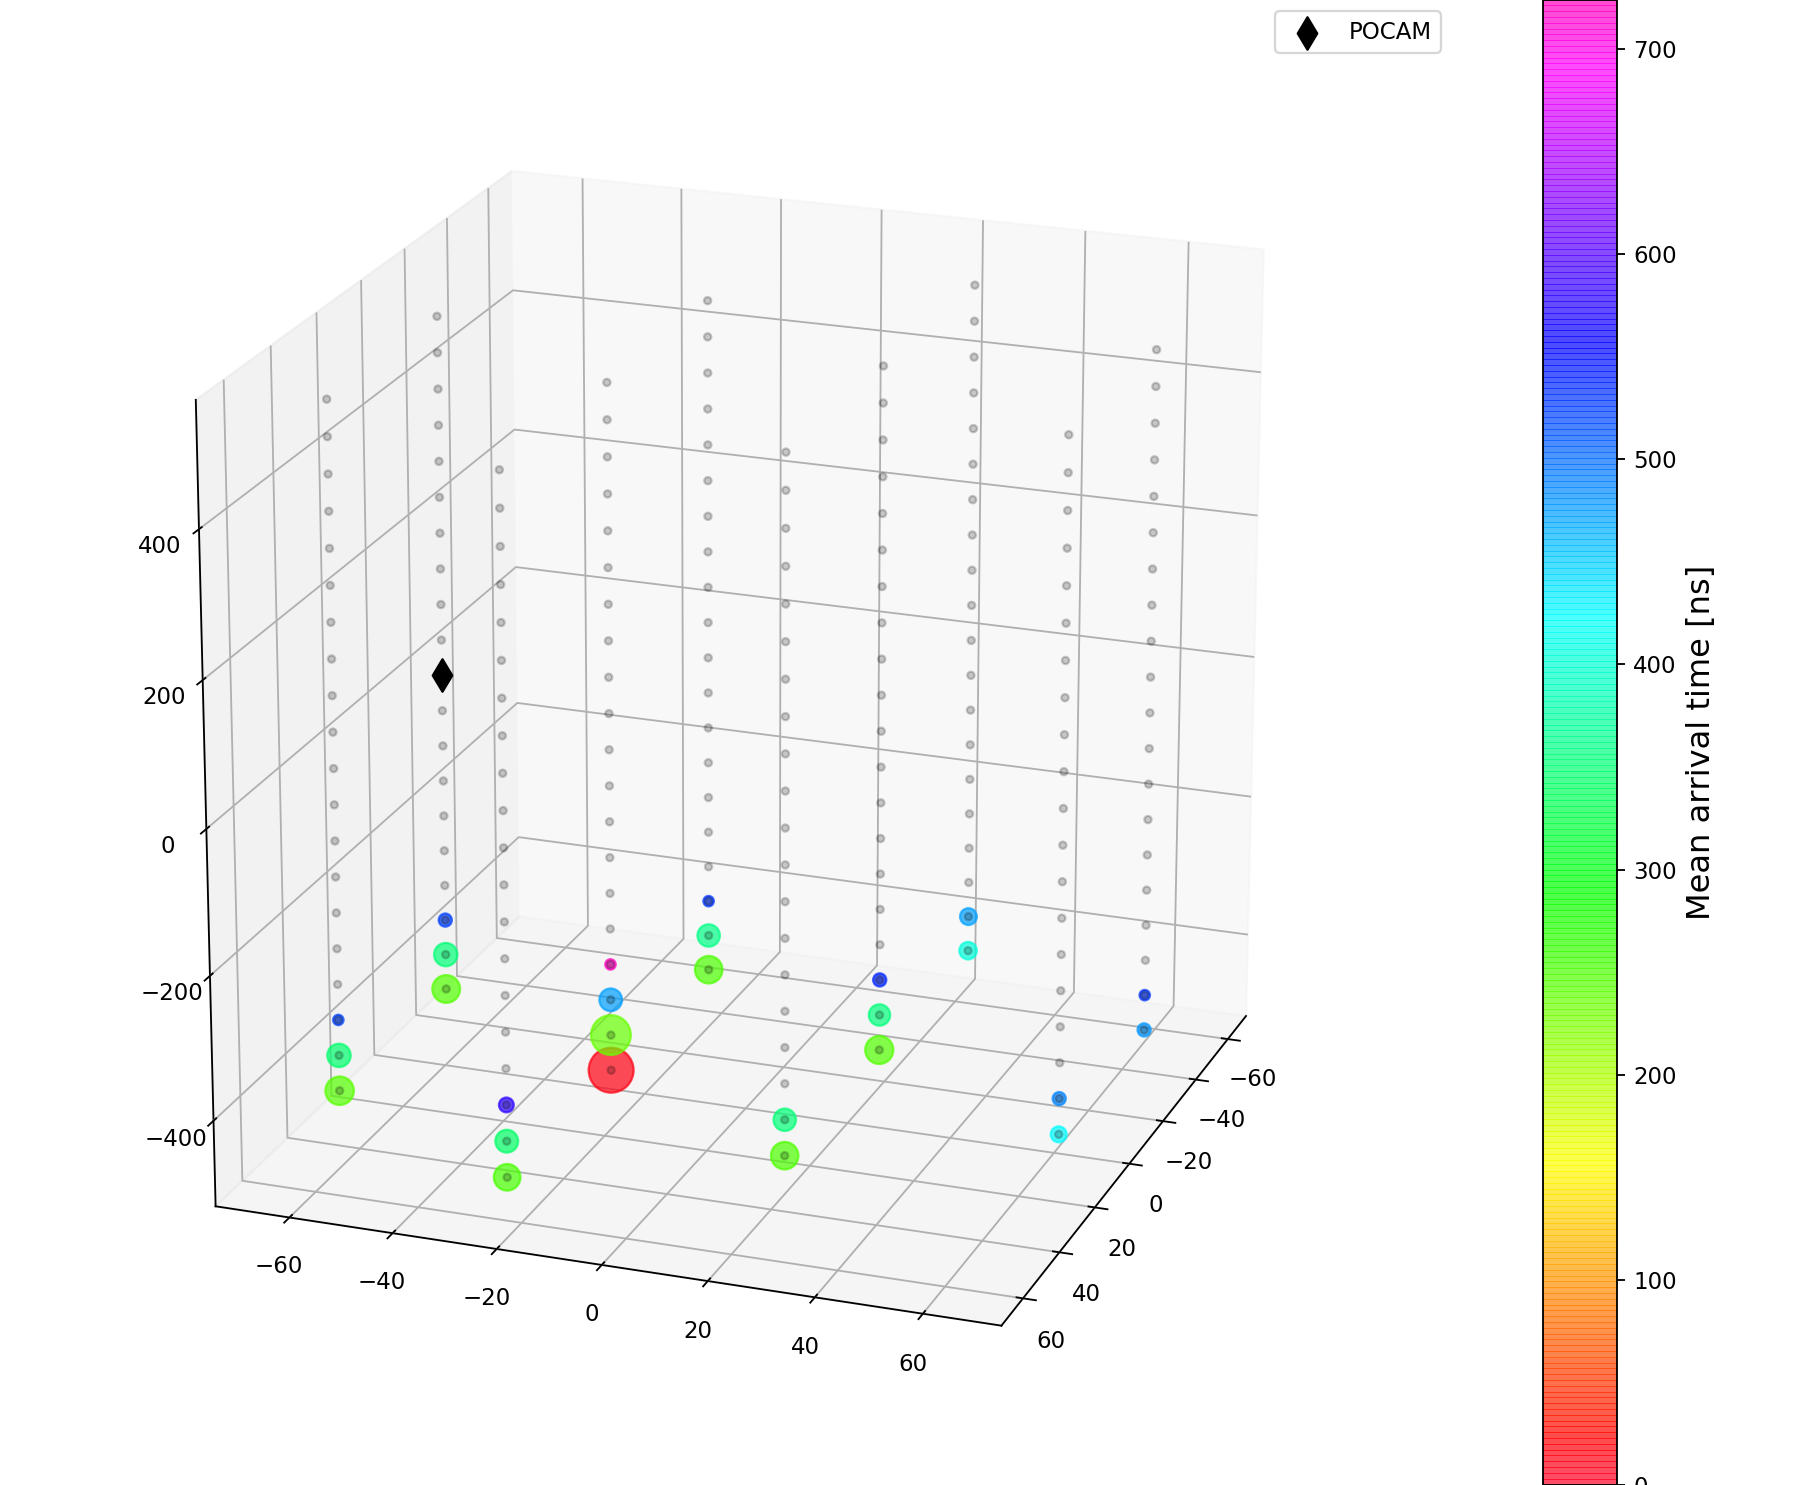

In [236]:
flasher_key=OMKey(5, 10, 1)

fig = plt.figure(figsize=(11,9))
ax = Axes3D(fig)

# DOM arrays for plotting DOMs as black dots
x_doms_d=[]
y_doms_d=[]
z_doms_d=[]

# DOM arrays for plotting hit DOMs 
x_doms=[]
y_doms=[]
z_doms=[]
times=[]
sizes=[]

for key in event.keys():
    i = OMKey(key[0], key[1], 1)
    x_doms_d.append(geo.omgeo[i].position.x)
    y_doms_d.append(geo.omgeo[i].position.y)
    z_doms_d.append(geo.omgeo[i].position.z)

    if data_dict[key][0] != 0: # only look at hit DOMs and ignore upgrade modules (+distance limit)
        x_doms.append(geo.omgeo[i].position.x)
        y_doms.append(geo.omgeo[i].position.y)
        z_doms.append(geo.omgeo[i].position.z)
        times.append(data_dict[key][2]) # time as color
        sizes.append(30*np.log(data_dict[key][0] + 1)) # counts as size (scaling is arbitrary in this case)

# detector
p = ax.scatter(x_doms_d, y_doms_d, z_doms_d, c='k', s=10, alpha=0.2)

# hits
p = ax.scatter(x_doms, y_doms, z_doms, c=times, cmap='gist_rainbow', vmin=0, vmax=np.max(times), s=sizes, alpha=0.7)
cbar = fig.colorbar(p)
cbar.set_label("Mean arrival time [ns]", fontsize=14)

# flasher
p = ax.scatter(geo.omgeo[flasher_key].position.x,
               geo.omgeo[flasher_key].position.y,
               geo.omgeo[flasher_key].position.z,
               s=100, c='k', marker='d', label='POCAM',
               zorder=0)

ax.view_init(20, 20)
ax.legend(loc="upper right")
plt.show()

---

In [237]:
for key in data_dict:
    q = data_dict[key][0]
    if q > 1:
        print(key, q)

ModuleKey(1,1) 362215
ModuleKey(1,2) 22896
ModuleKey(1,3) 25
ModuleKey(2,1) 118
ModuleKey(2,2) 23
ModuleKey(3,1) 88
ModuleKey(3,2) 26
ModuleKey(3,3) 3
ModuleKey(4,1) 171
ModuleKey(4,2) 31
ModuleKey(5,1) 132
ModuleKey(5,2) 31
ModuleKey(5,3) 2
ModuleKey(6,1) 118
ModuleKey(6,2) 23
ModuleKey(7,1) 148
ModuleKey(7,2) 17
ModuleKey(7,3) 2
ModuleKey(8,1) 4
ModuleKey(8,2) 2
ModuleKey(9,1) 6
ModuleKey(9,2) 5
ModuleKey(10,1) 2


<IPython.core.display.Javascript object>


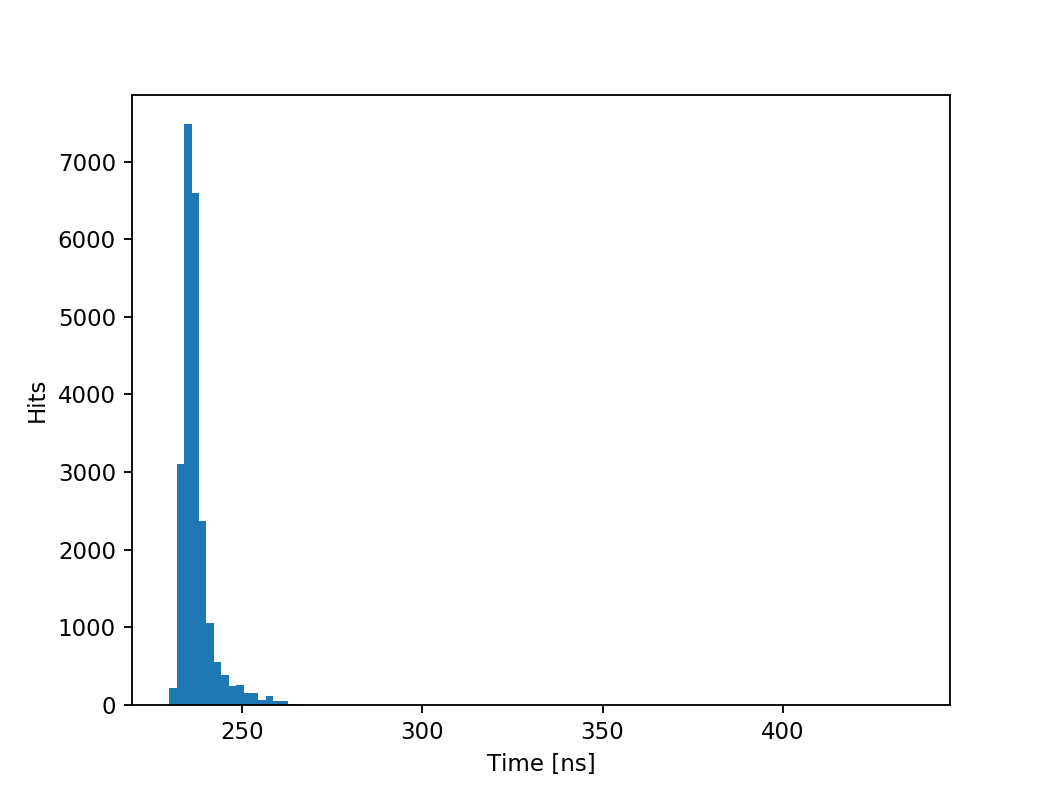

In [239]:
plt.figure()
plt.hist(data_dict[ModuleKey(1, 2)][1], bins=100)
# plt.yscale('log')
plt.xlabel('Time [ns]')
plt.ylabel('Hits')
plt.show()

<IPython.core.display.Javascript object>


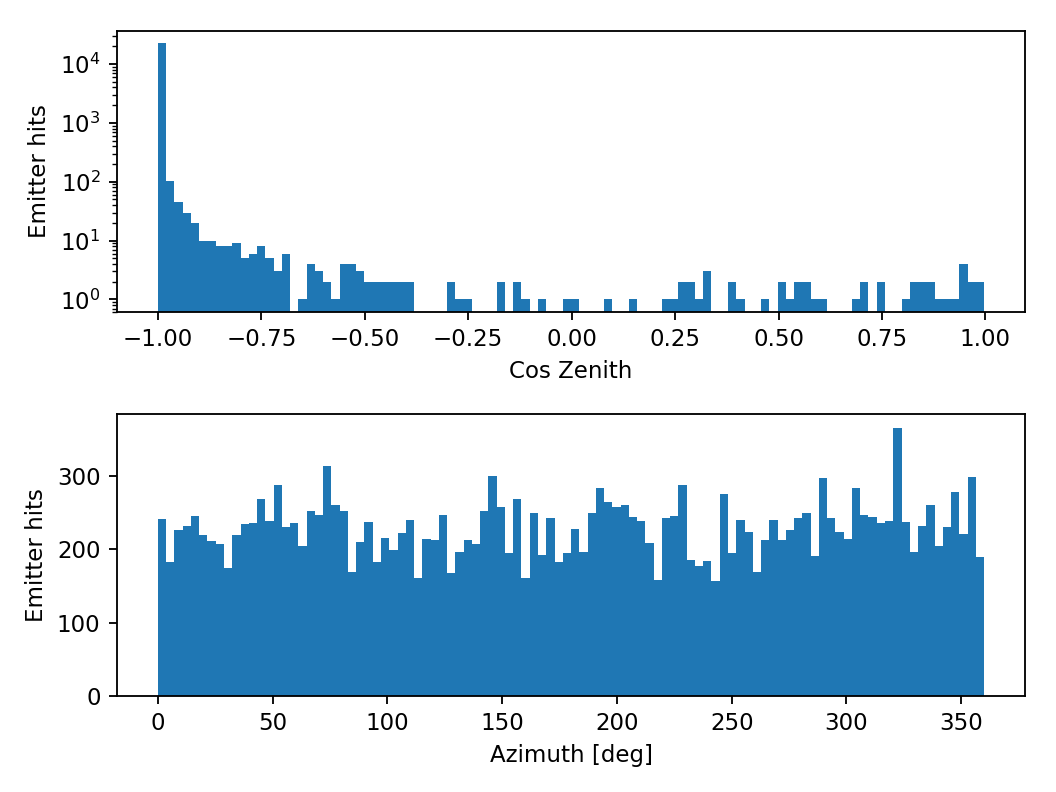

In [241]:
data = data_dict[ModuleKey(5,10)]

plt.figure()
ax1 = plt.subplot(211)
ax1.hist(np.cos(data[3]), bins=100)#, weights=np.sin(data[3]))
ax1.set_xlabel('Cos Zenith')
ax1.set_ylabel('Emitter hits')
ax1.set_yscale('log')
# ax1.set_ylim(1e0, None)

ax2 = plt.subplot(212)
ax2.hist(np.rad2deg(data[4]), bins=100)
ax2.set_xlabel('Azimuth [deg]')
ax2.set_ylabel('Emitter hits')

plt.tight_layout()
plt.show()

---

## Calculate hits vs distance

In [230]:
i3f.rewind()

In [ ]:
# iterate this many frames
n = 1

# empty array for storage
# format [distance, cosine angle, charge, mean hit time]
data = np.zeros((len(all_dom_keys), 6))

# we define the flasher_key
fkey = OMKey(5, 10, 1)
f_x, f_y, f_z = geo.omgeo[fkey].position
f_dir = geo.omgeo[fkey].direction

# then we read in the i3 file and iterate
for i in range(n):
    
    data_tmp_fr = i3f.pop_daq() # pop photon frame
    data_tmp_i = data_tmp_fr['I3Photons'] # get photon objects
    
    for cntr, key in enumerate(all_dom_keys): 
        
        if key in data_tmp_i.iteritems():
            
            j = data_tmp_i[key]
            
            string = j[0][0]
            dom    = j[0][1]
            okey = OMKey(string, dom, 1)

            # extract hits
            times = [k.time for k in j[1]]
            hits = len(times)

            # get vectors
            r_x, r_y, r_z = geo.omgeo[okey].position
            v = np.array([r_x - f_x, r_y - f_y, r_z - f_z])

            # calculate distance
            distance = np.sqrt(np.dot(v,v))

            # calculate angle between emitter/receiver
            v1 = np.array([f_dir.x, f_dir.y, f_dir.z])
            v2 = v
            costheta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
            costheta = 0 if np.isnan(costheta) else costheta

            # store
            data[cntr][0] = distance
            data[cntr][1] = costheta
            data[cntr][2] = hits
            data[cntr][3] = np.mean(times)/n
            data[cntr][4] = string
            data[cntr][5] = dom
            
            print('%s %s %.2f %.2f %i' %(fkey, okey, distance, costheta, hits))
        
        else:
            pass
          
    if i%10 == 0 and i > 0:
        print('%i frames processed.' %(i))

<IPython.core.display.Javascript object>


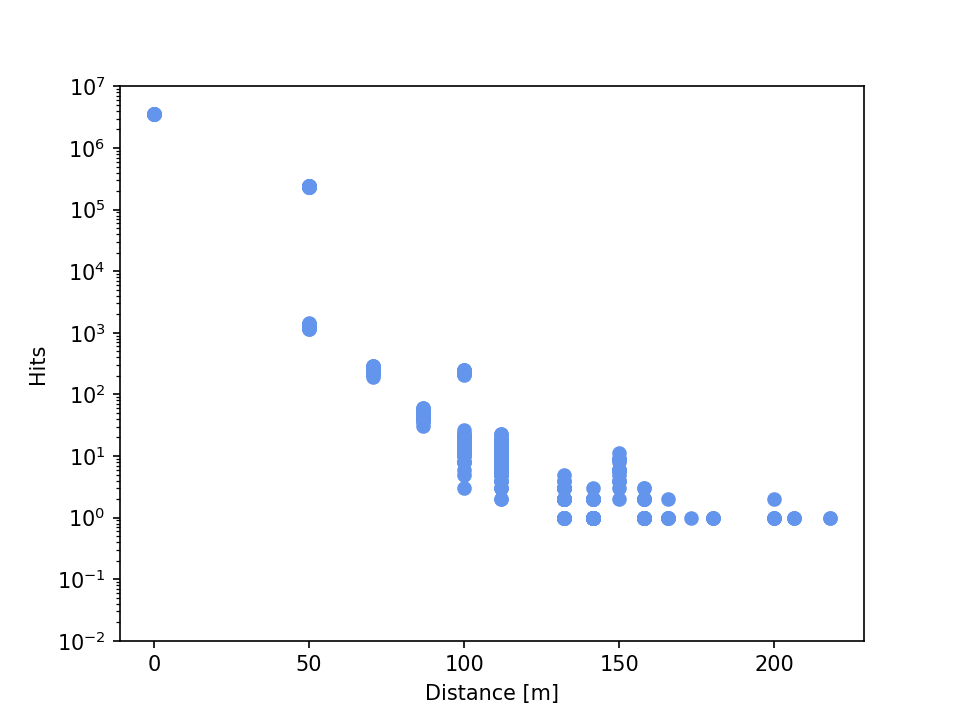

In [226]:
plt.figure()
sc = plt.scatter(data[:,0][m], data[:,2][m], c='cornflowerblue')
# plt.errorbar(data[:,0], data[:,2], yerr=np.sqrt(data[:,2]), fmt='o', ms=0, zorder=-10, c='cornflowerblue')
plt.xlabel('Distance [m]')
plt.ylabel('Hits')
plt.yscale('log')
plt.ylim(1e-2, 1e7)
plt.show()

<IPython.core.display.Javascript object>


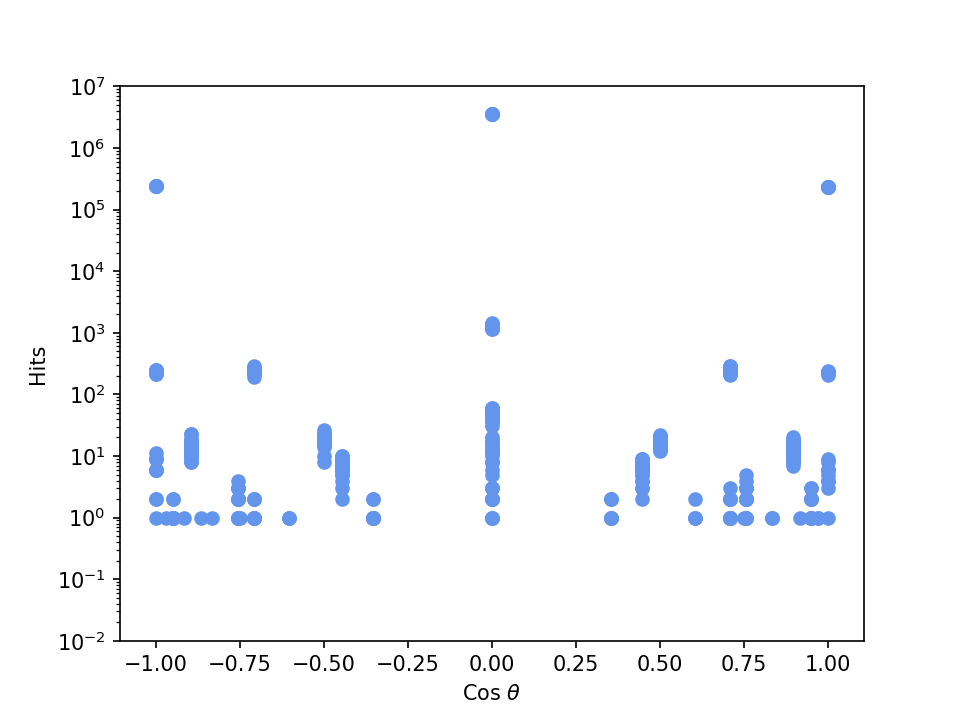

In [227]:
plt.figure()
m = (data[:,1] != np.nan)
sc = plt.scatter(data[:,1][m], data[:,2][m], c='cornflowerblue')
# plt.errorbar(data[:,1], data[:,2], yerr=np.sqrt(data[:,2]), fmt='o', ms=0, zorder=-10, c='cornflowerblue')
plt.xlabel('Cos $\\theta$')
plt.ylabel('Hits')
plt.yscale('log')
plt.ylim(1e-2, 1e7)
plt.show()

<IPython.core.display.Javascript object>


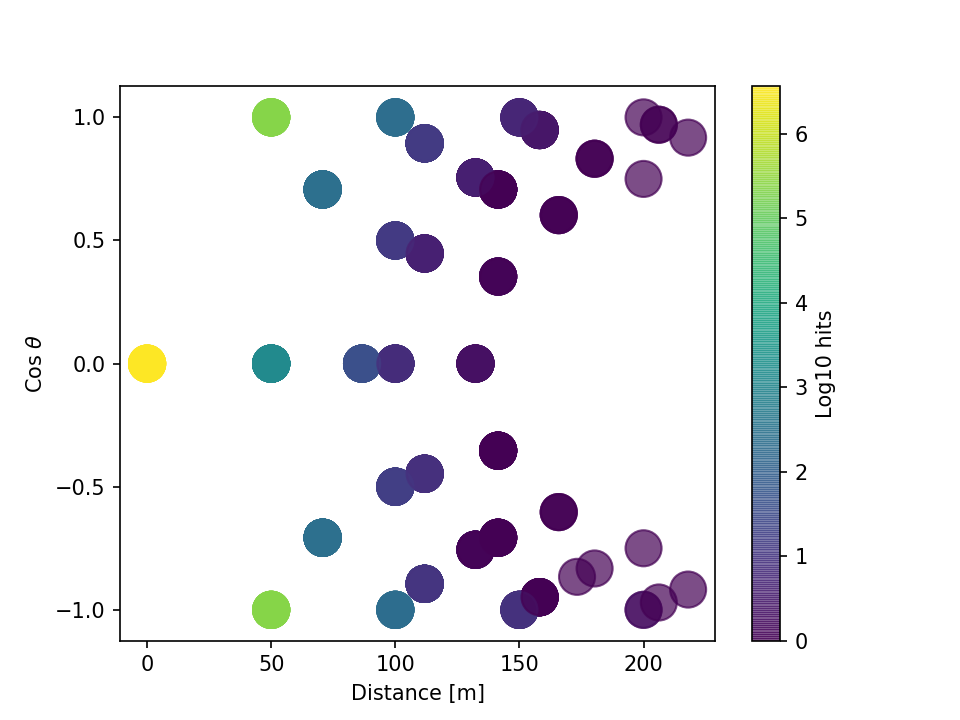

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


In [228]:
plt.figure()
sc = plt.scatter(data[:,0][m], data[:,1][m], c=np.log10(data[:,2][m]), alpha=0.7, s=300)
plt.colorbar(sc, label='Log10 hits')
plt.xlabel('Distance [m]')
plt.ylabel('Cos $\\theta$')
plt.show()

<IPython.core.display.Javascript object>


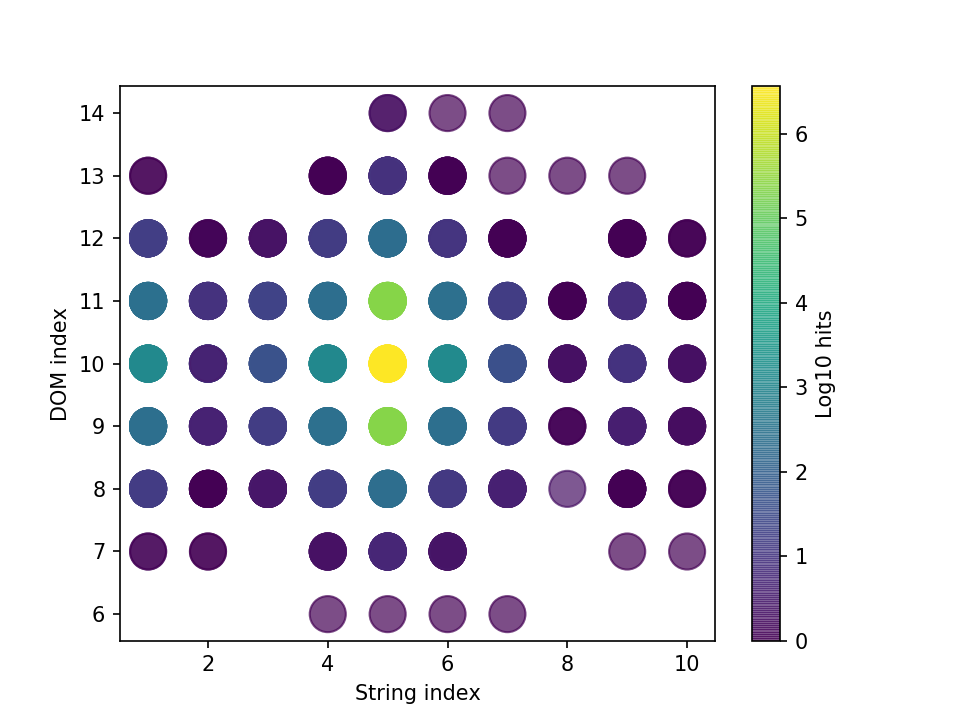

/cvmfs/icecube.opensciencegrid.org/py3-v4.1.1/Ubuntu_20.04_x86_64/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


In [229]:
plt.figure()
sc = plt.scatter(data[:,4][m], data[:,5][m], c=np.log10(data[:,2][m]), alpha=0.7, s=300)
plt.colorbar(sc, label='Log10 hits')
plt.xlabel('String index')
plt.ylabel('DOM index')
plt.show()

---

Could this be caused by using a hole ice parameterization where there shouldn't be one?

<IPython.core.display.Javascript object>


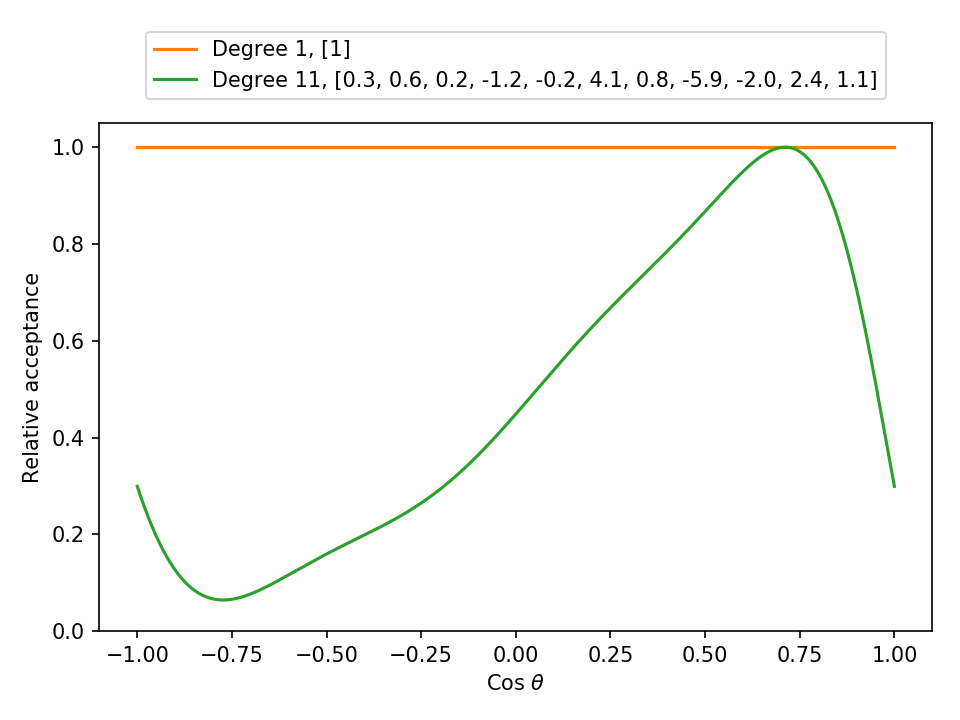

In [97]:
from numpy import polynomial as pn

x = np.linspace(-1, 1, 1001)
norm   = 1
coeffs = [[1], [0.3, 0.6, 0.2, -1.2, -0.2, 4.1, 0.8, -5.9, -2.0, 2.4, 1.1]]

plt.figure()
plt.plot(x, np.ones(x.shape))

for c in coeffs:
    p = pn.Polynomial(c)
    plt.plot(x, p(x) * norm/np.max(p(x)), label='Degree %i, %s' %(len(c), c))
          
plt.xlabel('Cos $\\theta$')
plt.ylabel('Relative acceptance')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

How does the angular emission look like directly in the emitter OM?

In [ ]:
i3f.rewind()

---

# Estimate coverage

In [193]:
args = np.load(os.path.join(os.environ.get('PONEDATA'), d, 'submit', 'arguments.npy'), allow_pickle=True).item()

In [194]:
keys = [OMKey(int(k.split('-')[0]), int(k.split('-')[1]), 1) for k in args['flasher-key']]

## Calculate distances

In [195]:
distances = []

for key in keys:
    e_x, e_y, e_z = geo.omgeo[key].position
    
    for okey in all_dom_keys:
        r_x, r_y, r_z = geo.omgeo[okey].position
        
        distance = np.sqrt((e_x - r_x)**2 + (e_y - r_y)**2 + (e_z - r_z)**2)
        distances.append(distance)

<IPython.core.display.Javascript object>


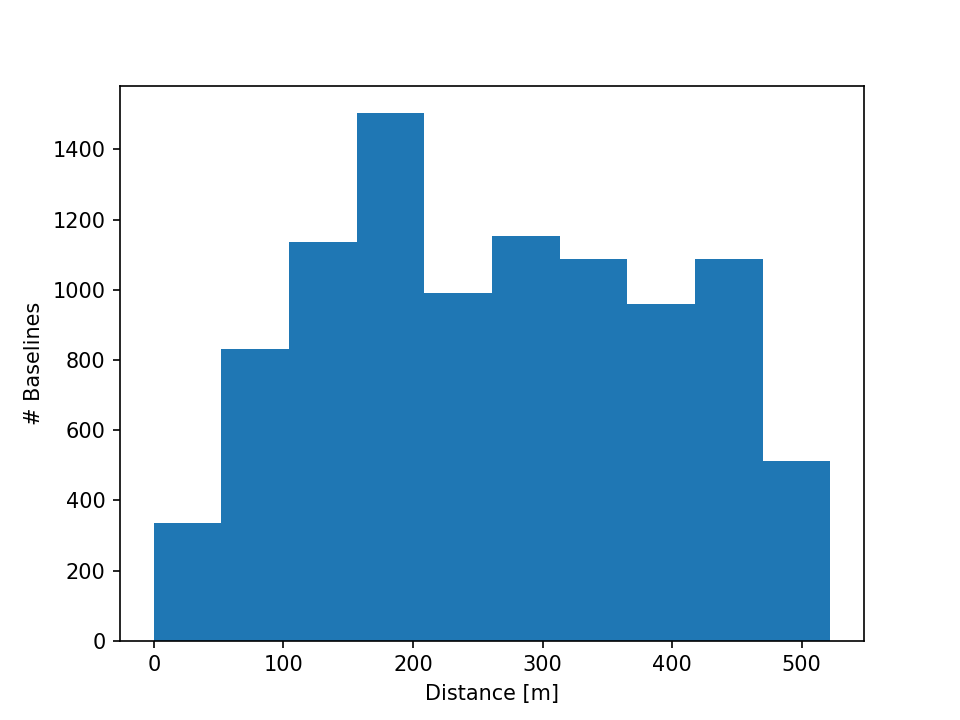

In [196]:
plt.figure()
plt.hist(distances, bins=10)
plt.xlabel('Distance [m]')
plt.ylabel('# Baselines')
plt.show()